In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import itertools
from itertools import product
rng = np.random

In [13]:
# This will return an array representing N rolls of n dD
def dice_roll(n=1,D=6,N=1):
    return np.random.randint(1,D+1,(N,n))

In [14]:
# Roll N rolls of n dD sided dice, return their sums in the array values 
# and a dictionary that compiles how many times each sum appears, roll_dict
def sum_rolls(n=1,D=6,N=1):
    roll_dict = {}
    rolls = dice_roll(n,D,N)
    values = np.sum(rolls,axis=1)
    min_value = np.min(values)
    max_value = np.max(values)
    for i in range(min_value,max_value+1):
        roll_dict[i] = np.sum(values==i)
    return roll_dict,values

In [15]:
# Return counts of roll outcomes from N trials of rolling n dD and substracting the min
def subtract_min(n=4,D=6,N=100):
    roll_dict={}
    rolls = dice_roll(n,D,N)
    values = np.sum(rolls,axis=1)-np.min(rolls,axis=1)
    min_value = np.min(values)
    max_value = np.max(values)
    for i in range(min_value,max_value+1):
        roll_dict[i] = np.sum(values==i)
    return roll_dict,values

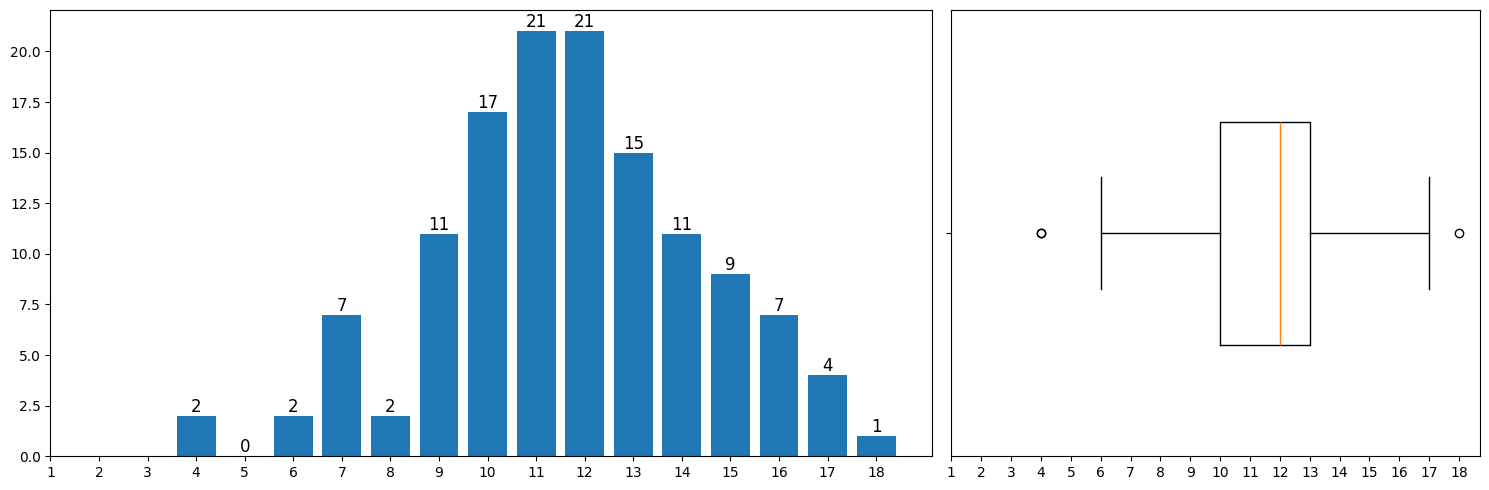

In [16]:
# Creates a bar chart and box plot side by side using raw and compiled data.

# Collect/generate the data 
temp_dict,raw_values = subtract_min(4,6,130)

# Initialize the figure
fig,axis = plt.subplots(1,2,figsize=(15,5),width_ratios=[5,3])

# Create bar chart using compiled data values
bars = axis[0].bar(temp_dict.keys(),temp_dict.values());
axis[0].bar_label(bars,fontsize=12)

# Create box plot using the raw values
axis[1].boxplot(raw_values,orientation="horizontal",tick_labels=[""],widths=0.5);
axis[0].set_xticks(range(1,19));
axis[1].set_xticks(range(1,19));

# Adjust the layout for the figure
fig.tight_layout()
# fig.savefig("../images/atribute_rolls_trial1.png",bbox_inches='tight',transparent=True);

In [17]:
# Sample commands to create values from particular distributions
print(rng.normal(0,0.5,size=10))
print(rng.uniform(-5,5,10))
print(np.random.binomial(10, 1/3, 10))
print(sum(np.random.binomial(9, 0.1, 20000) == 0)/20000)

[ 0.282856    0.24164006 -0.92137396  0.61879555 -0.03581675  0.55710537
  0.84737338  0.00206708 -0.09085114 -0.387747  ]
[ 0.25172386 -2.31472791 -2.0754533   0.46464264 -2.83458047  4.27642986
  0.93450345 -1.91287435  1.39314938  3.98987195]
[4 3 5 2 3 5 4 2 5 5]
0.393


In [21]:
# Original array of number of trials (n)
trials_array = np.array([10, 20, 30, 40])
p = 0.5  # Probability of success

# Map binomial distribution onto each element
# Each element in trials_array is treated as 'n'
binomial_results = np.random.binomial(n=trials_array, p=p)

print(f"Original Trials: {trials_array}")
print(f"Random Samples:  {binomial_results}")

Original Trials: [10 20 30 40]
Random Samples:  [ 6  8  8 19]


In [42]:
# Create table of test trials with 
# 90-110 participants
# averaging 75% positive tests
# averageing 25% false positives
# deviate the values by a normal distribution with mean 0 and stdev 0.5?
Trials = 10
Participants = rng.randint(90,110,Trials)
Positive_Tests = rng.binomial(Participants,0.75)
True_Positives = rng.binomial(Positive_Tests,0.75)
Percent_Correct = True_Positives/Positive_Tests*100
Compiled_Table = np.array([np.arange(1,11),Participants,Positive_Tests,True_Positives,Percent_Correct.astype(int)])
Compiled_Table.transpose()

array([[  1, 103,  79,  61,  77],
       [  2,  98,  71,  59,  83],
       [  3, 108,  83,  59,  71],
       [  4, 101,  76,  57,  75],
       [  5,  99,  69,  54,  78],
       [  6,  94,  68,  49,  72],
       [  7, 107,  84,  69,  82],
       [  8, 107,  82,  61,  74],
       [  9, 103,  78,  60,  76],
       [ 10, 107,  80,  59,  73]])

In [52]:
df = pd.DataFrame(Compiled_Table.transpose(), columns=['Trial', 'Participant', 'Positives', 'True Positives' , 'Percent Correct'])
Trial_Table = df.style.to_latex(column_format="c|c|c|c|c",hrules=False)

In [53]:
print(Trial_Table)

\begin{tabular}{c|c|c|c|c}
 & Trial & Participant & Positives & True Positives & Percent Correct \\
0 & 1 & 103 & 79 & 61 & 77 \\
1 & 2 & 98 & 71 & 59 & 83 \\
2 & 3 & 108 & 83 & 59 & 71 \\
3 & 4 & 101 & 76 & 57 & 75 \\
4 & 5 & 99 & 69 & 54 & 78 \\
5 & 6 & 94 & 68 & 49 & 72 \\
6 & 7 & 107 & 84 & 69 & 82 \\
7 & 8 & 107 & 82 & 61 & 74 \\
8 & 9 & 103 & 78 & 60 & 76 \\
9 & 10 & 107 & 80 & 59 & 73 \\
\end{tabular}



In [45]:
with open("../input_files/trial_table.tex", "w", encoding="utf-8") as f:
    f.writelines(Trial_Table)